In [1]:
import json
import warnings
from typing import Any, Literal

import numpy as np
import pandas as pd
import polars as pl
from rich.console import Console
from rich.theme import Theme

custom_theme = Theme(
    {
        "white": "#FFFFFF",  # Bright white
        "info": "#00FF00",  # Bright green
        "warning": "#FFD700",  # Bright gold
        "error": "#FF1493",  # Deep pink
        "success": "#00FFFF",  # Cyan
        "highlight": "#FF4500",  # Orange-red
    }
)
console = Console(theme=custom_theme)

# Visualization
# import matplotlib.pyplot as plt

# NumPy settings
np.set_printoptions(precision=4)

# Pandas settings
pd.options.display.max_rows = 1_000
pd.options.display.max_columns = 1_000
pd.options.display.max_colwidth = 600

# Polars settings
pl.Config.set_fmt_str_lengths(1_000)
pl.Config.set_tbl_cols(n=1_000)
pl.Config.set_tbl_rows(n=200)

warnings.filterwarnings("ignore")

# Black code formatter (Optional)
%load_ext lab_black

# auto reload imports
%load_ext autoreload
%autoreload 2

In [2]:
def go_up_from_current_directory(*, go_up: int = 1) -> None:
    """This is used to up a number of directories.

    Params:
    -------
    go_up: int, default=1
        This indicates the number of times to go back up from the current directory.

    Returns:
    --------
    None
    """
    import os
    import sys

    CONST: str = "../"
    NUM: str = CONST * go_up

    # Goto the previous directory
    prev_directory = os.path.join(os.path.dirname(__name__), NUM)
    # Get the 'absolute path' of the previous directory
    abs_path_prev_directory = os.path.abspath(prev_directory)

    # Add the path to the System paths
    sys.path.insert(0, abs_path_prev_directory)
    print(abs_path_prev_directory)


# Demo (Prevents ruff from removing the unused module import)
name: Any
category: Literal["A", "B", "C"]
json.loads('{"name": "Bike Rental Prediction", "category": "A"}')

{'name': 'Bike Rental Prediction', 'category': 'A'}

In [3]:
go_up_from_current_directory(go_up=2)

from model_config import LocalModel, RemoteModel  # noqa: E402
from settings import refresh_settings  # noqa: E402

settings = refresh_settings()

/Users/mac/Desktop/Projects/RAG-Tutorials


In [4]:
from langchain_openai import ChatOpenAI

model_str_remote: str = RemoteModel.X_AI_GROK_4_FAST
# model_str2_remote: str = RemoteModel.QWEN3_30B_A3B
model_str_local: str = LocalModel.LLAMA3_1_8B

remote_llm = ChatOpenAI(
    api_key=settings.OPENROUTER_API_KEY.get_secret_value(),  # type: ignore
    base_url=settings.OPENROUTER_URL,
    temperature=0.0,
    model=model_str_remote,
)


local_llm = ChatOpenAI(
    api_key=settings.LMSTUDIO_API_KEY.get_secret_value(),
    base_url=settings.LMSTUDIO_URL,
    temperature=0.0,
    model=model_str_local,
)

# Test the LLMs
response = remote_llm.invoke("Tell me a very short joke.")
response.pretty_print()

================================== Ai Message ==================================

Why don't scientists trust atoms? Because they make up everything!


# Tools

Tools are external functions, integrations, or services that AI agents invoke to extend their capabilities beyond internal reasoning or training data.

In [5]:
from langchain_core.messages import (
    AIMessage,
    AnyMessage,
    HumanMessage,
    SystemMessage,
    ToolMessage,
)
from langchain_core.tools import tool

In [6]:
@tool
def addition_tool(a: float, b: float) -> float:
    """
    Adds two numbers together.

    Parameters
    ----------
    a : float
        First number to add.
    b : float
        Second number to add.

    Returns
    -------
    float
        The sum of a and b.
    """
    return a + b


@tool
def multiplication_tool(a: float, b: float) -> float:
    """
    Multiplies two numbers together.

    Parameters
    ----------
    a : float
        First number to multiply.
    b : float
        Second number to multiply.

    Returns
    -------
    float
        The product of a and b.
    """
    return a * b


@tool
def weather_tool(location: str) -> str:
    """
    Gets the current weather for a given location.

    Parameters
    ----------
    location : str
        The location for which to get the weather.

    Returns
    -------
    str
        A string describing the current weather.
    """
    return f"The current weather in {location} is sunny with a temperature of 25°C."

In [ ]:
tools: list[Any] = [addition_tool, multiplication_tool, weather_tool]
llm_with_tools = remote_llm.bind_tools(tools)
system_instruction: str = """
<INSTRUCTIONS>
You are a helpful assistant. You MUST use the tools provided to answer the user's questions except when the 
user is asking for general information that does not require tool usage.
</INSTRUCTIONS>
"""
messages: list[AnyMessage] = [
    SystemMessage(content=system_instruction),
    HumanMessage(content="What is 5 + 3?"),
]

response = llm_with_tools.invoke(messages)
response.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  addition_tool (call_32475132)
 Call ID: call_32475132
  Args:
    a: 5
    b: 3


In [8]:
console.print(response)

AIMessage(
    content='',
    additional_kwargs={
        'tool_calls': [
            {
                'id': 'call_32475132',
                'function': {'arguments': '{"a":5,"b":3}', 'name': 'addition_tool'},
                'type': 'function',
                'index': 0
            }
        ],
        'refusal': None
    },
    response_metadata={
        'token_usage': {
            'completion_tokens': 168,
            'prompt_tokens': 616,
            'total_tokens': 784,
            'completion_tokens_details': {
                'accepted_prediction_tokens': None,
                'audio_tokens': None,
                'reasoning_tokens': 131,
                'rejected_prediction_tokens': None
            },
            'prompt_tokens_details': None
        },
        'model_name': 'x-ai/grok-4-fast',
        'system_fingerprint': None,
        'id': 'gen-1761040263-8XPsSjdZmO6W7CqpDp4r',
        'service_tier': None,
        'finish_reason': 'tool_calls',
        'logprobs': None
    },
    id='run--092bd24c-f6ab-49d0-8d0c-cdb9486a9088-0',
    tool_calls=[{'name': 'addition_tool', 'args': {'a': 5, 'b': 3}, 'id': 'call_32475132', 'type': 'tool_call'}],
    usage_metadata={
        'input_tokens': 616,
        'output_tokens': 168,
        'total_tokens': 784,
        'input_token_details': {},
        'output_token_details': {'reasoning': 131}
    }
)

<br><hr>

## Reducers

- Reducers in LangGraph are functions that define how updates from graph nodes are merged into the overall state. 

- They are a key mechanism for managing state evolution in a controlled, predictable way. 

- Each key (field) in the state schema can have its own independent reducer. 

- If no reducer is specified for a key, the default behavior is to override the existing value with the new update—simple but potentially destructive for accumulative data like message histories.

In [9]:
from typing import Annotated, TypedDict

from langgraph.graph.message import add_messages


class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

### Reducers with `add_messages`

In [10]:
initial_messages: list[AnyMessage] = [
    SystemMessage(content="You are a helpful assistant."),
    HumanMessage(content="Hello! Tell me a short story."),
    AIMessage(content="Sure! Once upon a time, in a land far away..."),
]

other_messages: list[AnyMessage] = [
    HumanMessage(content="Can you add 10 and 20 for me?"),
    AIMessage(content="Sure! The sum of 10 and 20 is 30."),
    HumanMessage(content="What of 5 multiplied by 6?"),
    AIMessage(content="5 multiplied by 6 is 30."),
]


res = add_messages(initial_messages, other_messages)
console.print(res)

[
    SystemMessage(
        content='You are a helpful assistant.',
        additional_kwargs={},
        response_metadata={},
        id='38ae949c-0d7e-49b4-87db-7552a870cb38'
    ),
    HumanMessage(
        content='Hello! Tell me a short story.',
        additional_kwargs={},
        response_metadata={},
        id='3ce1d417-44ff-451f-9b6c-a0bdc7caaa35'
    ),
    AIMessage(
        content='Sure! Once upon a time, in a land far away...',
        additional_kwargs={},
        response_metadata={},
        id='ed5e1d5d-763e-4e21-a3b6-b6197e7de73e'
    ),
    HumanMessage(
        content='Can you add 10 and 20 for me?',
        additional_kwargs={},
        response_metadata={},
        id='34011c07-da12-477f-b744-a62562970e98'
    ),
    AIMessage(
        content='Sure! The sum of 10 and 20 is 30.',
        additional_kwargs={},
        response_metadata={},
        id='fdbd2860-132a-4043-b7a9-4334f3bb2d28'
    ),
    HumanMessage(
        content='What of 5 multiplied by 6?',
        additional_kwargs={},
        response_metadata={},
        id='75016a43-4a84-4c90-8322-2a7e45848781'
    ),
    AIMessage(
        content='5 multiplied by 6 is 30.',
        additional_kwargs={},
        response_metadata={},
        id='ad3c4373-bf73-470b-8533-755c92f07ad5'
    )
]

In [11]:
async def llm_tool(state: State) -> dict[str, Any]:
    sys_msg = SystemMessage(content=system_instruction)
    response = await llm_with_tools.ainvoke([sys_msg] + state["messages"])

    return {"messages": [response]}

In [12]:
from IPython.display import Image, display
from langgraph.graph import END, START, StateGraph

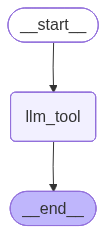

In [13]:
builder: StateGraph = StateGraph(State)

# Nodes
builder.add_node("llm_tool", llm_tool)

# Edges
builder.add_edge(START, "llm_tool")
builder.add_edge("llm_tool", END)

# Build
graph = builder.compile()

# Visualize the graph
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [14]:
messages: list[AnyMessage] = [HumanMessage(content="Can you add 10 and 20 for me?")]
response = await graph.ainvoke({"messages": messages})

In [15]:
for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Can you add 10 and 20 for me?
================================== Ai Message ==================================
Tool Calls:
  addition_tool (call_70014246)
 Call ID: call_70014246
  Args:
    a: 10
    b: 20


<br>

### Add Tool Node

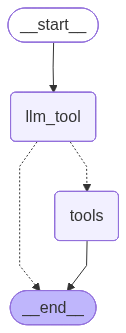

In [16]:
from langgraph.prebuilt import ToolNode, tools_condition

tool_node = ToolNode(tools)
builder: StateGraph = StateGraph(State)

# Nodes
builder.add_node("llm_tool", llm_tool)
builder.add_node("tools", tool_node)


# Edges
builder.add_edge(START, "llm_tool")
builder.add_conditional_edges(
    "llm_tool",
    # if the last AI message contains tool calls, route to the tool execution node;
    # otherwise, end the workflow.
    # llm_tool -> tools OR llm_tool -> END
    tools_condition,
)
# Redundant edge for clarity
builder.add_edge("llm_tool", END)

# Build
graph = builder.compile()

# Visualize the graph
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [17]:
messages: list[AnyMessage] = [HumanMessage(content="Can you add 10 and 20 for me?")]
response = await graph.ainvoke({"messages": messages})

for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Can you add 10 and 20 for me?
================================== Ai Message ==================================
Tool Calls:
  addition_tool (call_99011315)
 Call ID: call_99011315
  Args:
    a: 10
    b: 20
================================= Tool Message =================================
Name: addition_tool

30.0


In [ ]:
messages: list[AnyMessage] = [HumanMessage(content="What is the temperature in Aba right now?")]
response = await graph.ainvoke({"messages": messages})

for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

What is the temperature in Aba right now?
================================== Ai Message ==================================
Tool Calls:
  weather_tool (call_08214236)
 Call ID: call_08214236
  Args:
    location: Aba
================================= Tool Message =================================
Name: weather_tool

The current weather in Aba is sunny with a temperature of 25°C.


In [19]:
messages: list[AnyMessage] = [HumanMessage(content="What is eight times three?")]
response = await graph.ainvoke({"messages": messages})

for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

What is eight times three?
================================== Ai Message ==================================
Tool Calls:
  multiplication_tool (call_65907363)
 Call ID: call_65907363
  Args:
    a: 8
    b: 3
================================= Tool Message =================================
Name: multiplication_tool

24.0


# ReAct Architecture

- A ReAct agent is an AI agent that uses the `“reasoning and acting”` (ReAct) framework to combine chain of thought (CoT) reasoning with external tool use. The ReAct framework enhances the ability of a large language model (LLM) to handle complex tasks and decision-making in agentic workflows.

- First introduced by Yao and others in the 2023 paper, “ReACT: Synergizing Reasoning and Acting in Language Models,” ReAct can be understood most generally as a machine learning (ML) paradigm to integrate the reasoning and action-taking capabilities of LLMs.

## ReAct Agent Loop

[![image.png](https://i.postimg.cc/CxH5WP1t/image.png)](https://postimg.cc/HrnTMtb4)

In [20]:
from langchain_tavily import TavilySearch

tavily_search = TavilySearch(
    api_key=settings.TAVILY_API_KEY.get_secret_value(),
    max_results=3,
    topic="general",
)
tavily_search.invoke({"query": "What is LangGraph?"})

{'query': 'What is LangGraph?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.datacamp.com/tutorial/langgraph-tutorial',
   'title': 'LangGraph Tutorial: What Is LangGraph and How to Use It?',
   'content': 'LangGraph is a library within the LangChain ecosystem that provides a framework for defining, coordinating, and executing multiple LLM agents (or chains) in a structured and efficient manner. By managing the flow of data and the sequence of operations, LangGraph allows developers to focus on the high-level logic of their applications rather than the intricacies of agent coordination. Whether you need a chatbot that can handle various types of user requests or a multi-agent system that performs complex tasks, LangGraph provides the tools to build exactly what you need. LangGraph significantly simplifies the development of complex LLM applications by providing a structured framework for managing state and coordinating agent interactio

In [ ]:
# Force the model to use ANY tool (will choose the most appropriate one)
# This is ONLY used without agents.
print("=== Option 1: tool_choice='any' (Tool Call Only) ===")
response_any = remote_llm.bind_tools(
    [tavily_search],
    tool_choice="any",
).invoke(
    [
        SystemMessage(content="You are a helpful assistant that uses search results."),
        HumanMessage(content="Who is the pope?"),
    ]
)
response_any.pretty_print()

# Now execute the tool and get the final answer
print("\n=== Executing the tool and getting final answer ===")

# Execute the tool call
tool_call = response_any.tool_calls[0]
tool_result = tavily_search.invoke({"query": tool_call["args"]["query"]})

# Send the tool result back to the model for final answer
final_response = remote_llm.invoke(
    [
        SystemMessage(content="You are a helpful assistant that uses search results."),
        HumanMessage(content="Who is the pope?"),
        response_any,  # The AI message with tool calls
        ToolMessage(content=str(tool_result), tool_call_id=tool_call["id"]),
    ]
)
print("\n=== Final Answer ===")
final_response.pretty_print()

=== Option 1: tool_choice='any' (Tool Call Only) ===
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_65572369)
 Call ID: call_65572369
  Args:
    query: current pope

=== Executing the tool and getting final answer ===

=== Final Answer ===
================================== Ai Message ==================================

**Pope Leo XIV** is the current pope, elected on May 8, 2025, during the 2025 papal conclave. He succeeded Pope Francis as the 267th pope of the Roman Catholic Church. (Note: Some sources still reference Pope Francis, but the most up-to-date information points to Leo XIV.)


In [22]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper, WikipediaAPIWrapper

In [23]:
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=1_000)
arxiv_tool = ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv_tool.name)

api_wrapper_wiki = WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=1_000)
wiki_tool = WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
print(wiki_tool.name)

arxiv
wikipedia


In [24]:
wiki_tool.invoke("Who is the current Pope?")

'Page: List of current popes and patriarchs\nSummary: This is a list of current Christian popes and patriarchs..'

In [25]:
arxiv_tool.invoke("`Attention is all you need`")

"Published: 2024-07-22\nTitle: Attention Is All You Need But You Don't Need All Of It For Inference of Large Language Models\nAuthors: Georgy Tyukin, Gbetondji J-S Dovonon, Jean Kaddour, Pasquale Minervini\nSummary: The inference demand for LLMs has skyrocketed in recent months, and serving\nmodels with low latencies remains challenging due to the quadratic input length\ncomplexity of the attention layers. In this work, we investigate the effect of\ndropping MLP and attention layers at inference time on the performance of\nLlama-v2 models. We find that dropping dreeper attention layers only marginally\ndecreases performance but leads to the best speedups alongside dropping entire\nlayers. For example, removing 33\\% of attention layers in a 13B Llama2 model\nresults in a 1.8\\% drop in average performance over the OpenLLM benchmark. We\nalso observe that skipping layers except the latter layers reduces performances\nfor more layers skipped, except for skipping the attention layers.\n\n

In [26]:
async def llm_tool(state: State) -> dict[str, Any]:
    sys_msg = SystemMessage(content=system_instruction)
    response = await llm_with_tools.ainvoke([sys_msg] + state["messages"])

    return {"messages": [response]}

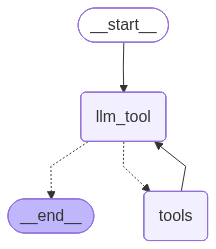

In [ ]:
tools: list[Any] = [
    addition_tool,
    multiplication_tool,
    weather_tool,
    arxiv_tool,
    tavily_search,
    wiki_tool,
]

llm_with_tools = remote_llm.bind_tools(tools)

builder = StateGraph(State)

# Nodes
tool_node = ToolNode(tools)
builder.add_node("llm_tool", llm_tool)
builder.add_node("tools", tool_node)

# Edges
builder.add_edge(START, "llm_tool")
builder.add_conditional_edges(
    "llm_tool",
    # llm -> tools OR llm -> END
    tools_condition,
)
builder.add_edge("tools", "llm_tool")

# Compile
graph = builder.compile()

# Visualize
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [28]:
messages: list[AnyMessage] = [
    HumanMessage(
        content="What paper is `Attention is all you need`? What is the sum of -2.3 and 4.52? Multiply the result by 0.05"
    )
]
response = await graph.ainvoke({"messages": messages})

for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

What paper is `Attention is all you need`? What is the sum of -2.3 and 4.52? Multiply the result by 0.05
================================== Ai Message ==================================
Tool Calls:
  arxiv (call_21626764)
 Call ID: call_21626764
  Args:
    query: Attention is all you need
  addition_tool (call_30790102)
 Call ID: call_30790102
  Args:
    a: -2.3
    b: 4.52
================================= Tool Message =================================
Name: arxiv

Published: 2024-07-22
Title: Attention Is All You Need But You Don't Need All Of It For Inference of Large Language Models
Authors: Georgy Tyukin, Gbetondji J-S Dovonon, Jean Kaddour, Pasquale Minervini
Summary: The inference demand for LLMs has skyrocketed in recent months, and serving
models with low latencies remains challenging due to the quadratic input length
complexity of the attention layers. In this work, we investigate the effect o

In [ ]:
messages: list[AnyMessage] = [HumanMessage(content="What is AI? Who is the current Pope?")]
response = await graph.ainvoke({"messages": messages})

for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

What is AI? Who is the current Pope?
================================== Ai Message ==================================
Tool Calls:
  wikipedia (call_12827915)
 Call ID: call_12827915
  Args:
    query: Current Pope
================================= Tool Message =================================
Name: wikipedia

Page: Pope
Summary: The pope is the bishop of Rome and the head of the worldwide Catholic Church. He is also known as the supreme pontiff, Roman pontiff, or sovereign pontiff. From the 8th century until 1870, the pope was the sovereign or head of state of the Papal States, and since 1929 of the much smaller Vatican City State. From a Catholic viewpoint, the primacy of the bishop of Rome is largely derived from his role as the apostolic successor to Saint Peter, to whom primacy was conferred by Jesus, who gave Peter the Keys of Heaven and the powers of "binding and loosing", naming him as the "rock" 

<br><hr>

# Agent Memory

- Agent memory refers to mechanisms that enable agents to store, retrieve, and manage information across interactions. 

- This allows agents to maintain context, learn from past experiences, and make more informed decisions over time, mimicking human-like recall. 

- Without memory, agents would treat each interaction in isolation, leading to repetitive or incoherent behavior.

In [30]:
# Without memory

messages: list[AnyMessage] = [HumanMessage(content="What is the product of 3 and 1.5?")]
response = await graph.ainvoke({"messages": messages})

for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

What is the product of 3 and 1.5?
================================== Ai Message ==================================
Tool Calls:
  multiplication_tool (call_80757023)
 Call ID: call_80757023
  Args:
    a: 3
    b: 1.5
================================= Tool Message =================================
Name: multiplication_tool

4.5
================================== Ai Message ==================================

The product of 3 and 1.5 is 4.5.


In [ ]:
messages: list[AnyMessage] = [HumanMessage(content="Subtract 0.5 from the result of your previous operation")]
response = await graph.ainvoke({"messages": messages})

for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Subtract 0.5 from the result of your previous operation
================================== Ai Message ==================================

I'm sorry, but this appears to be the start of our conversation, so there is no previous operation or result for me to reference. If you can provide more context or clarify what you'd like me to calculate (e.g., starting with specific numbers), I'd be happy to help using the available tools!


### MemorySaver

- A Checkpointer in LangGraph is a persistence mechanism that automatically saves snapshots (called checkpoints) of the graph's state at every super-step during execution. 

- This enables stateful applications, such as multi-turn conversations, human-in-the-loop workflows, or resilient agents that can resume from interruptions. 

- By compiling a graph with a checkpointer, LangGraph handles saving and loading state to a backend (e.g., in-memory, database), using threads (unique IDs like session tokens) to organize checkpoints across runs. 

- This builds on LangGraph's state management (e.g., via TypedDict schemas and reducers) to provide memory-like persistence without manual intervention.

In [44]:
from IPython.display import Image, display
from langchain_core.runnables import RunnableConfig
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, StateGraph

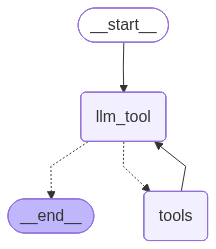

In [45]:
tools: list[Any] = [
    addition_tool,
    multiplication_tool,
    weather_tool,
    arxiv_tool,
    tavily_search,
    wiki_tool,
]

# IMPORTANT: Rebind tools WITHOUT tool_choice="any" to avoid infinite loops
llm_with_tools = remote_llm.bind_tools(tools)

builder = StateGraph(State)

# Nodes
tool_node = ToolNode(tools)
builder.add_node("llm_tool", llm_tool)
builder.add_node("tools", tool_node)

# Edges
builder.add_edge(START, "llm_tool")
builder.add_conditional_edges(
    "llm_tool",
    # llm -> tools OR llm -> END
    tools_condition,
)
builder.add_edge("tools", "llm_tool")

# Compile with memory
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

# Visualize
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [46]:
# With memory. Specify the thread ID to isolate the memory for this session
config = RunnableConfig(configurable={"thread_id": "session_1", "recursion_limit": 100})
messages: list[AnyMessage] = [HumanMessage(content="What is the product of 3 and 1.5?")]
response = await graph.ainvoke({"messages": messages}, config=config)

for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

What is the product of 3 and 1.5?
================================== Ai Message ==================================
Tool Calls:
  multiplication_tool (call_49504487)
 Call ID: call_49504487
  Args:
    a: 3
    b: 1.5
================================= Tool Message =================================
Name: multiplication_tool

4.5
================================== Ai Message ==================================

The product of 3 and 1.5 is 4.5.


In [ ]:
messages: list[AnyMessage] = [HumanMessage(content="Subtract 0.5 from the result of your previous operation")]
response = await graph.ainvoke({"messages": messages}, config=config)

for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

What is the product of 3 and 1.5?
================================== Ai Message ==================================
Tool Calls:
  multiplication_tool (call_49504487)
 Call ID: call_49504487
  Args:
    a: 3
    b: 1.5
================================= Tool Message =================================
Name: multiplication_tool

4.5
================================== Ai Message ==================================

The product of 3 and 1.5 is 4.5.
================================ Human Message =================================

Subtract 0.5 from the result of your previous operation
================================== Ai Message ==================================
Tool Calls:
  addition_tool (call_07713003)
 Call ID: call_07713003
  Args:
    a: 4.5
    b: -1.5
================================= Tool Message =================================
Name: addition_tool

3.0
================================== Ai Message ====

In [ ]:
messages: list[AnyMessage] = [HumanMessage(content="What was the first question I asked you?")]
response = await graph.ainvoke({"messages": messages}, config=config)

for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

What is the product of 3 and 1.5?
================================== Ai Message ==================================
Tool Calls:
  multiplication_tool (call_49504487)
 Call ID: call_49504487
  Args:
    a: 3
    b: 1.5
================================= Tool Message =================================
Name: multiplication_tool

4.5
================================== Ai Message ==================================

The product of 3 and 1.5 is 4.5.
================================ Human Message =================================

Subtract 0.5 from the result of your previous operation
================================== Ai Message ==================================
Tool Calls:
  addition_tool (call_07713003)
 Call ID: call_07713003
  Args:
    a: 4.5
    b: -1.5
================================= Tool Message =================================
Name: addition_tool

3.0
================================== Ai Message ====

## Structured Output

- Structured output refers to generating responses in a predefined, machine-readable format that strictly follows a specific schema.
- This is crucial for applications requiring precise data extraction, integration with other systems, or adherence to specific formats (e.g., JSON, XML).
- By enforcing structured output, developers can ensure consistency, facilitate downstream processing, and improve the reliability of AI-generated content.

In [ ]:
from pydantic import BaseModel, Field


class Employee(BaseModel):
    name: str = Field(..., description="The full name of the employee")
    id: int | None = Field(default=None, description="The unique identifier for the employee")
    department: str = Field(..., description="The department where the employee works")
    role: str = Field(..., description="The job role of the employee")
    salary: float = Field(..., description="The annual salary of the employee in USD")


input_text: str = """
Ethan Cole, a software engineer in the Machine Intelligence Department at Novatek Systems, earns $150,000 per year 
building scalable AI pipelines. His days oscillate between debugging neural networks and optimizing data flow for 
predictive analytics. Outside work, he's an avid cyclist, guitarist, and open-source contributor. On weekends, he 
tinkers with a smart home automation project powered by edge AI, aiming to make energy usage adaptive and efficient. 
Recently, he started developing a Python-based productivity tracker that uses sentiment analysis to gauge focus 
levels. To Ethan, every line of code is a quiet pursuit of elegance, logic, and impact.
"""

llm_with_structured_output = remote_llm.with_structured_output(Employee)
response = llm_with_structured_output.invoke(input_text)
response

Employee(name='Ethan Cole', id=None, department='Machine Intelligence Department', role='software engineer', salary=150000.0)

### Using Instructor

```sh
uv add instructor
```

In [ ]:
import instructor
from openai import AsyncOpenAI

_async_client = AsyncOpenAI(
    api_key=settings.OPENROUTER_API_KEY.get_secret_value(),
    base_url=settings.OPENROUTER_URL,
)

aclient = instructor.from_openai(
    _async_client, mode=instructor.Mode.OPENROUTER_STRUCTURED_OUTPUTS
)


# Define hook functions (Optional)
def log_kwargs(**kwargs):
    console.print(f"Function called with kwargs: {kwargs}")


def log_response(response: Any, **kwargs):
    console.print(f"Response: {response}")


def log_exception(exception: Exception):
    console.print(f"An exception occurred: {str(exception)}")


aclient.on("completion:kwargs", log_kwargs)
aclient.on("completion:error", log_exception)
aclient.on("completion:response", log_response)

employee = await aclient.chat.completions.create(
    model=RemoteModel.X_AI_GROK_4_FAST,
    response_model=Employee,
    messages=[{"role": "user", "content": input_text}],
)
employee

Function called with kwargs: {'messages': [{'role': 'user', 'content': "\nEthan Cole, a software engineer in the 
Machine Intelligence Department at Novatek Systems, earns $150,000 per year \nbuilding scalable AI pipelines. His 
days oscillate between debugging neural networks and optimizing data flow for \npredictive analytics. Outside work,
he's an avid cyclist, guitarist, and open-source contributor. On weekends, he \ntinkers with a smart home 
automation project powered by edge AI, aiming to make energy usage adaptive and efficient. \nRecently, he started 
developing a Python-based productivity tracker that uses sentiment analysis to gauge focus \nlevels. To Ethan, 
every line of code is a quiet pursuit of elegance, logic, and impact.\n"}], 'model': <RemoteModel.X_AI_GROK_4_FAST:
'x-ai/grok-4-fast'>, 'response_format': {'type': 'json_schema', 'json_schema': {'name': 'Employee', 'schema': 
{'properties': {'name': {'description': 'The full name of the employee', 'title': 'Name', 'type': 'string'}, 'id': 
{'anyOf': [{'type': 'integer'}, {'type': 'null'}], 'default': None, 'description': 'The unique identifier for the 
employee', 'title': 'Id'}, 'department': {'description': 'The department where the employee works', 'title': 
'Department', 'type': 'string'}, 'role': {'description': 'The job role of the employee', 'title': 'Role', 'type': 
'string'}, 'salary': {'description': 'The annual salary of the employee in USD', 'title': 'Salary', 'type': 
'number'}}, 'required': ['name', 'department', 'role', 'salary'], 'title': 'Employee', 'type': 'object', 
'additionalProperties': False}, 'strict': True}}}

Response: ChatCompletion(id='gen-1761043020-ybW6hDKeUWJpcJd1uCqs', choices=[Choice(finish_reason='stop', index=0, 
logprobs=None, message=ChatCompletionMessage(content=' {"name":"Ethan Cole","id":null,"department":"Machine 
Intelligence Department","role":"software engineer","salary":150000}', refusal=None, role='assistant', 
annotations=None, audio=None, function_call=None, tool_calls=None, reasoning=None, reasoning_details=[{'type': 
'reasoning.encrypted', 'data': 
'riYHjrP2VSyGPv3y3JqVhdvQUE6aKek0wUJeVqf76XsW2mtfrfCH65rh7dmOYugd2hhSCQ6n1Cl21G88nb8SO1b1iOWSv6FPcFEZnr52TAmtIJeDIF
2pfFbeVCdnsBEQgAfcRPyY9xBX/PCdb2Z+6NbpRELr2EKqN9rkxfX1yrFbXhpvURVNqzAn4n6FUqmj5IEqqIDBa3z69jLOinx9V3gEw1UAcREBpt81X
xbNbkqsZktemRr8NuyCiZwD9//K/onnymmMx5O/fMm6UaXmUTx6IT/cCWPLMtOdofTvBBOx7UD7Ao7JZaxGJrgnQu7ZRIOXoTvyCv/AaKnjojVyorqb
pU0PB8INOnPTRPI2msl1ircVZuNKIZCPWphLveB42eoxcSGK0SkK5s9tpO/EzkM8zU5yUUuzBROaFZzDcyrjbj7Bgnfxj7QXgLier2E1Qx//uOb+bdw
VkJebnfjA6GTjndL/XDJ3u0UZnNbrZ92REBMcgFx9BV7GC9ctOlhgNUCqiuzOWqd39xfChUdTzl5qYobEO5nNFI+hMKGYeNRupHDFIZwwQ1f2N1fJyD
TcSzIjFr17y5UA2uKY1P+u3unHnMTq4ldEiRR/jI7fxP0Ls0WMOybRV1k0aG6VrBMSY1oUchZbzz29gnaUDc6IVdOIKX5ecQ+nzB7W3PKVrf6T0sE5W
uNjb6kJKV0l5fVdkymyshcjq1Lfq16lLHUurjPwV57GcIFKwx+Yy1JaOJJ4WF06ppq+b72f+TJxiph/A94mvO8i94+Wbvjd9FGT9gywL+2kfkNMJwpd
B3Fihh9D35nvufOVKNw7/bfH2jZ9eKVEbncuETKgFnam4pfIYEG9enYmHLVBLKANb1H0qX7wIis8elfJ3qL/iZx2kFGaN4zfXQH6GkF8yMXIFpSHAZr
9CENMedO66N+nmmHvPFB2bJbrnskOI8P3UvZtnxRtCSuQXGMbTev3TCT4fdIcU+xRkig90FEt+WTE8qLk+7XyjB6RfvWKCJc/yV9LyTwmDXGmVEIh2r
OGlwXaaRrm5/W5F0Sxo0ZlArqis0MKhtbYDb5/pzQli2ultIruLi2LPUUuZNFfQEeMEUWTzlZbuw9TKHw8LIRVyC5cARy848TtUGzJA/08NPJCdc2rf
g7bwqRfWTJ1W8basBEfTd5b7xdbRlCpAQvW7utdZc38cFdxaJmMelJetUkvu3oN+eYJu5ZD+rBEKGvwLATEpyZj8Dv6qJ13dnB5RLUtnosz1bIJzk2o
QsgpJWoPjeoOMHJJPzpGrxX9bWXqAFwgmZ/TRZdX4EEqtjrWhf7K98fNW1V29gam/AQ0S0TCW1C3/ewsWjwBzNs6yC6onaZPg0Ho8Xhh0PerhoDAaZk
Gomsg3rGnvoq1/RCm+z23lj+LEA2bwQhiyg3abpDVzJf4/g+MtIeByNDdbQBqGjs8w3Skf2fE42gG/od1sJBdLIg3RIimjeJUaz6lU/q/26apxettXD
6dPnHxDc/UOJ7ogd4deBSCNOj2tyeP/shIeu5bgBlssZxDC5X8VeSr6iVrUWNCxtTgfqd2qTMOFvDxyd2GekUdXB8Xf43g71TS/slfVcOc8lmaz93o+
hs3pn5gYNzyBaZY8Jh/OmjvmXb7i63ehEFqm3EPVGHpMhpNtgivLJemjwx89wntJIR0RURP851C8/oTShC+T39jlxlxDoG2KdiHKICSVbT7jRmG9XpI
9O7ZD8i771S2F3fbx591UcwEBDRPQy7CTIUgLfmIgS8bxAwY3nWOR38NeyB8cWJgp1OWbsvtX8SeyAGqGgQxEDpg8BJekK3RU6RyQFhj/784Iq/yZVQ
BeyzKV09KShQ', 'id': 'rs_588f2017-69b0-83f9-718b-21cbf026dbd5_us-east-1', 'format': 'xai-responses-v1', 'index': 
0}]), native_finish_reason='completed')], created=1761043020, model='x-ai/grok-4-fast', object='chat.completion', 
service_tier=None, system_fingerprint=None, usage=CompletionUsage(completion_tokens=366, prompt_tokens=454, 
total_tokens=820, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=None, 
audio_tokens=None, reasoning_tokens=340, rejected_prediction_tokens=None), prompt_tokens_details=None), 
provider='xAI')

Employee(name='Ethan Cole', id=None, department='Machine Intelligence Department', role='software engineer', salary=150000.0)